# Simple Point Depo Study

Single point depo에 대한 study와 debugging을 위한 NoteBook

기본적으로 `/nfs/data/1/yujin/wirecell-img-evaluation/data/pdhd/test_point_depo`하위의 데이터를 사용한다.

(2026-07-23 Update) 기존에 `drift_speed : 1.6 us/mm`를 `pdhd/params.jsonnet`에서 `drift_spee : 1.56 us/mm`로 override

In [30]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import matplotlib.pyplot as plt

from utils.load import *
from utils.depo_inspect import *
from utils.blob_inspect import *

from utils.slicer import *
from utils.vis.longitudinal_plots import *
from utils.vis.transverse_plots import *
from utils.vis.depo_3d import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Required Parameters

In [31]:
ANODE_INDEX = 1
RESPONSE_PLANE_X = 3430.47   # [mm]

V_DRIFT = 1.56   # [mm/us]
T_OFFSET = 0         
# T_OFFSET = 314.5         # [us]
# T_OFFSET = 314.1026      # [us]

WIRE_FILE = "/nfs/data/1/yujin/wirecell-img-evaluation/wire-cell-cfg/det_geo/protodunehd-wires-larsoft-v1.json.bz2"

DATA_BASE_PATH = "/nfs/data/1/yujin/wirecell-img-evaluation/data/pdhd"

# Utils

In [32]:
def convert_time2x(t_us, v_drift, response_plane_x):
    """Converts a time (us) to a physical x position (mm) using the drift velocity and anode position.

    Args:
        t_us (float): Time in microseconds.
        v_drift (float): Drift velocity in mm/us.
        response_plane_x (float): x position of the response plane in mm.

    Returns:
        float: Physical x position in mm.
    """
    return response_plane_x - v_drift * t_us

# Data Loading

In [33]:
sub_dir = "test_point_depo"

depo_file = os.path.join(DATA_BASE_PATH, sub_dir, "depos-drifted-1.zip")
blob_file = os.path.join(DATA_BASE_PATH, sub_dir, "clusters-apa-1.tar.gz")
bdf_file = os.path.join(DATA_BASE_PATH, sub_dir, "clusters-apa-bdf-1.tar.gz")


depo_post = load_generation_data(depo_file, 0)
depo_pre = load_generation_data(depo_file, 1)

blobs_graph = load_cluster_data(blob_file, 0)
bdf_graph = load_cluster_data(bdf_file, 0)

blobs = load_graph_nodes(blobs_graph, "b")
bdfs = load_graph_nodes(bdf_graph, "b")

# Point Deposition Analysis

### Inspection

In [34]:
depos_inspect(depo_post, depo_pre)


                        [ DEPOS INSPECTION (Gen 0 & Gen 1) ]                         
Container Type : <class 'dict'>
Dict Size      : 7 (Number of keys)
Data Keys      : ['t', 'q', 'x', 'y', 'z', 'L', 'T']
Data Types     : t(float32), q(float32), x(float32), y(float32)
                 z(float32), L(float32), T(float32)
# of Depos     : 1 (Gen 0 & 1 Match)
Total Memory   : 0.00 MB (Combined)
-------------------------------------------------------------------------------------
Quantity           | Gen 1 (Pre-drift)              | Gen 0 (Post-drift)            
-------------------------------------------------------------------------------------
Total q [e-]       | 5.00000e+04                    | 4.28840e+04                   
t Range [ns]       | 0.0 ~ 0.0                      | 1237477.6 ~ 1237477.6         
x [mm]             | 1500.0 ~ 1500.0                | 3430.5 ~ 3430.5               
y [mm]             | 3000.0 ~ 3000.0                | 3000.0 ~ 3000.0               
z [mm]

In [35]:
single_depo_inspect(depo_post, 0)
single_depo_inspect(depo_pre, 0)


                        [ Single Depo Inspection (Index: 0) ]                        
 Quantities                | Value               
-------------------------------------------------------------------------------------
 Total Charge (q) [e-]     | 4.28840e+04
 Charge in 3.0sigma [e-]   | 4.27682e+04 (99.73%)
-------------------------------------------------------------------------------------
 Time (t) [ns]             | 1237477.62
 (x,y,z) [mm]              | (3430.47, 3000.00, 1000.00)
 Long. Sigma (L) [mm]      | 1.3349    
 Tran. Sigma (T) [mm]      | 1.7234    
 Status                    | Post-drift 3D Gaussian

                        [ Single Depo Inspection (Index: 0) ]                        
 Quantities                | Value               
-------------------------------------------------------------------------------------
 Total Charge (q) [e-]     | 5.00000e+04
 Charge in 3.0sigma [e-]   | 4.98650e+04 (99.73%)
---------------------------------------------------------

#### Deposition Center

In [36]:
def depo_center(depos, depo_idx=0):
    """Returns the (x, y, z) center [mm] of a depo from pre-drif (Gen1) depo data.

    Args:
        depos (dict): Depos data loaded from a depos-drifted-<N>.zip file.
        depo_idx (int): Index of the depo to analyze.
    """
    t = depos["t"][depo_idx] / 1000.0  # [us]
    x = depos["x"][depo_idx]
    y = depos["y"][depo_idx]
    z = depos["z"][depo_idx]
    return np.array([t, x, y, z])


def depo_center_undrifted(depos, depo_idx=0, v_drift=V_DRIFT, t_offset=T_OFFSET, response_plane_x=RESPONSE_PLANE_X):
    """Recovers the pre-drift depo (x, y, z) center [mm] from post-drift (Gen0) depo data.

    Gen0's `t` already encodes the pure drift transit time (no frame offset
    applied), so `x = anode1_x_pos - v_drift * t_us` alone recovers the
    original x to sub-0.01mm accuracy (verified against Gen1 ground truth).
    No `t_offset` here: that offset only matters when converting a *reco-clock*
    time (e.g. a blob's slice `start`, see `blob_center`) into this same
    physical-drift-time clock; Gen0's `t` is already on it.
    """
    t_us = depos["t"][depo_idx] / 1000.0 + t_offset  # [us]
    # t_us = depos["t"][depo_idx] / 1000.0  # [us]
    
    x = convert_time2x(t_us, v_drift, response_plane_x)
    y = depos["y"][depo_idx]
    z = depos["z"][depo_idx]
    return np.array([t_us, x, y, z])

In [37]:
depo_center_pre = depo_center(depo_pre, 0)
depo_center_post = depo_center(depo_post, 0)
depo_center_post_undrifted = depo_center_undrifted(depo_post, 0)

print("Pre-Drift Center[mm]           :", depo_center_pre)
print("Post-Drift Center[mm]          :", depo_center_post)
print("Undrifted Post-Drift Center[mm]:", depo_center_post_undrifted)
print("Delta(Undrifted-Pre)[mm]       :", depo_center_post_undrifted - depo_center_pre)

Pre-Drift Center[mm]           : [   0. 1500. 3000. 1000.]
Post-Drift Center[mm]          : [1237.477625   3430.46508789 3000.         1000.        ]
Undrifted Post-Drift Center[mm]: [1237.477625 1500.004905 3000.       1000.      ]
Delta(Undrifted-Pre)[mm]       : [1.23747762e+03 4.90500000e-03 0.00000000e+00 0.00000000e+00]


### Slice

In [38]:
reference_t_us = 1518 
span = 2

sigma = depo_post["L"][0] / V_DRIFT  # [us] -- L is a spatial (mm) sigma along the drift axis; divide by v_drift to get the temporal (us) sigma, same as plot_depo_gaussian_long_ax's internal `sigma` and position_center_comparison.py's `sigma_ns`. (Previously left in mm, so this Binning's +/-n_sigma*sigma window was much wider than the true 3-sigma range.)
n_sigma = 3 

slices = Binning(depo_center_post_undrifted[0] - n_sigma*sigma, depo_center_post_undrifted[0] + n_sigma*sigma, span=span, reference=reference_t_us)

print( "sigma :", sigma)
print( "# of bins: ", slices.nbins())
print( "min val: ", slices.min())
print( "max val: ", slices.max())
print( "bin size: ", slices.binsize())
print( "span :", slices.span())
print( "1531 is contained in bin: ", slices.bin(1531))
print( "15th bin center: ", slices.center(15))
print( "Edge of 15th bin: ", slices.edge(15))
print( "Is 1531 contained? :", slices.inside(1531))
print( "Is 15th bin valid? :", slices.inbounds(15))

sigma : 0.8557074345075167
# of bins:  4
min val:  1234
max val:  1242
bin size:  2.0
span : 8
1531 is contained in bin:  148
15th bin center:  1265.0
Edge of 15th bin:  1264.0
Is 1531 contained? : False
Is 15th bin valid? : False


In [39]:
def depo_slice_center(depos, method, slice_start, slice_end, v_drift, t_offset, response_plane_x, depo_idx=0):
    """Depo (x, y, z) center restricted to one reco slice's time window.

    A single depo's diffusion Gaussian in time typically spans several reco
    slices, each producing its own reco blob; comparing every one of those
    blobs against the depo's global (untruncated) mean is not apples-to-
    apples, since a blob only captures the fraction of the depo's charge
    that falls inside its own slice.

    `method="truncated_mean"` (recommended) uses the truncated-normal mean
    of the depo's time-Gaussian within [slice_start, slice_end]
    (`truncated_gaussian_mean`), converted back to physical time/x with the
    same `t_us - t_offset` step as `blob_center` (both slice_start/slice_end
    and the truncated mean live on the reco clock). Any other `method` value
    falls back to the plain slice midpoint `(slice_start+slice_end)/2` --
    a cruder approximation that only matches the truncated mean near the
    depo's Gaussian peak; it systematically diverges (biased toward the
    slice's far edge) for slices in the tails, which is exactly where this
    analysis's outliers tend to show up, so use it only for side-by-side
    comparison against truncated_mean, not as the default.

    y/z are unaffected by time-slicing and match depo_center.
    """
    if method == "truncated_mean":
        mean_ns = depos["t"][depo_idx] + t_offset * 1000.0
        sigma_ns = (depos["L"][depo_idx] / v_drift) * 1000.0

        mean_us = truncated_gaussian_mean(slice_start, slice_end, mean_ns, sigma_ns) / 1000.0

        x = convert_time2x(mean_us - t_offset, v_drift, response_plane_x)
    else:
        mean_us = (slice_start + slice_end) / 2.0 / 1000.0
        x = convert_time2x(mean_us - t_offset, v_drift, response_plane_x)

    y = depos["y"][depo_idx]
    z = depos["z"][depo_idx]
    return np.array([mean_us, x, y, z])


In [40]:
trunc_mean = []
simple_mean = []

for i in range(slices.nbins()):
    i_trunc_mean = depo_slice_center(depo_post, "truncated_mean", slices.edge(i)*1000, slices.edge(i+1)*1000, V_DRIFT, T_OFFSET, RESPONSE_PLANE_X, 0)
    

    i_simple_mean = depo_slice_center(depo_post, "mean", slices.edge(i)*1000, slices.edge(i+1)*1000, V_DRIFT, T_OFFSET, RESPONSE_PLANE_X, 0)

    trunc_mean.append(i_trunc_mean[0])
    simple_mean.append(i_simple_mean[0])

    print(f"bin {i} ({slices.edge(i)} - {slices.edge(i+1)} ): Truncated Mean: {i_trunc_mean[0]}, Simple Mean: {i_simple_mean[0]}")

print(trunc_mean)
print(simple_mean)

bin 0 (1234.0 - 1236.0 ): Truncated Mean: 1235.6529589881375, Simple Mean: 1235.0
bin 1 (1236.0 - 1238.0 ): Truncated Mean: 1237.177130747718, Simple Mean: 1237.0
bin 2 (1238.0 - 1240.0 ): Truncated Mean: 1238.5137905655054, Simple Mean: 1239.0
bin 3 (1240.0 - 1242.0 ): Truncated Mean: 1240.245369284183, Simple Mean: 1241.0
[1235.6529589881375, 1237.177130747718, 1238.5137905655054, 1240.245369284183]
[1235.0, 1237.0, 1239.0, 1241.0]


### Plots

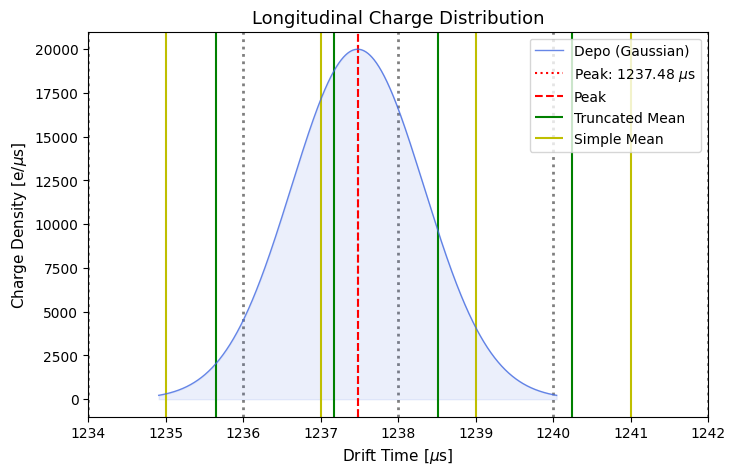

In [41]:
fig, ax = plt.subplots(figsize=(8, 5))

plot_depo_gaussian_long_ax(ax, depo_post, V_DRIFT, T_OFFSET, 0, 3, True)
plot_slice_edges_long_ax(ax, slices, True)
ax.axvline(depo_center_post_undrifted[0], color='r', linestyle='--', label='Peak')


ax.vlines(trunc_mean, ymin=0, ymax=1, color='g', linestyle='-', label='Truncated Mean', transform=ax.get_xaxis_transform())
ax.vlines(simple_mean, ymin=0, ymax=1, color='y', linestyle='-', label='Simple Mean', transform=ax.get_xaxis_transform())

ax.legend()
plt.show()

# Reconstructed Blob Analysis

In [42]:
blobs_slices = load_graph_nodes(blobs_graph, "s")
blobs_wires = load_graph_nodes(blobs_graph, "w")

In [43]:
summarize_slices(blobs_slices)


                            [ Slice Summary (4 slices) ]                             
Desc   | Frame ID  | Ident    | Start (ns)   | Span (ns) | Channel #    | Total Val 
------------------------------------------------------------------------------------
43     | 100       | 774      | 1233732.4    | 2000.0    | 12           | 13493.0   
63     | 100       | 775      | 1235732.4    | 2000.0    | 12           | 55638.0   
80     | 100       | 776      | 1237732.4    | 2000.0    | 14           | 52716.0   
90     | 100       | 777      | 1239732.4    | 2000.0    | 11           | 9637.0    
------------------------------------------------------------------------------------

>>> Full Signal List (Channel-by-Channel):

[Slice 0 | Start: 1233732.435897436 ns]
    Signals: ID:4368(v:1639)   ID:4367(v:638)    ID:3528(v:390)    
             ID:3915(v:957)    ID:3916(v:809)    ID:3563(v:1520)   
             ID:2887(v:881)    ID:2931(v:952)    ID:3170(v:547)    
             ID:3832(v:417)  


```
python blob_viewer/blob_web_server.py --blob-file data/pdhd/test_point_depo/clusters-apa-1.tar.gz --depo-file data/pdhd/test_point_depo/depos-drifted-1.zip --t-offset 0
```